# Introduction

**Team:** AIX  
**Project Name:** AgriTech Predictor  
The science of training machines to learn from data and generate models for future prediction has become increasingly important across many domains. Agriculture, in particular, plays a critical role in the global economy and human survival. With the continuous growth of the world’s population, understanding and accurately predicting crop yield has become central to addressing food security challenges and mitigating the effects of climate change.

Crop yield prediction is a vital agricultural problem, as yield is strongly influenced by several factors, including weather conditions such as rainfall and temperature, pesticide usage, and historical crop production data. Access to accurate and reliable yield information is essential for informed decision-making in agricultural risk management, resource optimization, and sustainable food production planning.


# Library Importing

In this project, the following Python libraries are imported to assist with data manipulation, visualization, statistical analysis, preprocessing, and machine learning modeling:

- **numpy**: Provides support for numerical operations, arrays, and mathematical functions.
- **pandas**: Used for loading, cleaning, merging, and exploring datasets.
- **matplotlib.pyplot**: A plotting library for creating static and interactive visualizations.
- **seaborn**: Built on matplotlib, it helps create attractive statistical plots with less code.

- **scipy.stats**: Provides statistical functions for analyzing distributions, calculating skewness, kurtosis, and conducting hypothesis tests.

- **sklearn.preprocessing**: Includes tools like `LabelEncoder` and `StandardScaler` for encoding categorical variables and standardizing features.
- **sklearn.model_selection**: Tools for splitting datasets into training and testing sets.
- **sklearn.linear_model**: Linear regression modeling.
- **sklearn.metrics**: Functions to evaluate model performance such as R² score, Mean Absolute Error (MAE), and Mean Squared Error (MSE).
- **sklearn.tree & ensemble**: Decision Tree and Random Forest regressors for supervised learning tasks.

- **lightgbm (LGB, LGBMRegressor)**: Gradient boosting framework for high-performance regression and classification.
- **catboost (CatBoostRegressor)**: Gradient boosting algorithm that handles categorical features efficiently.
- **xgboost (XGBRegressor)**: Extreme gradient boosting framework for efficient and accurate predictions.

- **warnings**: Suppresses unnecessary warning messages.
- **sns.set() & pandas display options**: Configures seaborn aesthetics and pandas to display all columns for easier inspection of the data.

These libraries provide a comprehensive toolkit for **data preprocessing, visualization, statistical analysis, and building machine learning models** in this crop yield prediction project.


In [1]:
# Import libraries for numerical computations
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import statistical functions for data analysis
from scipy.stats import skew, kurtosis
import scipy.stats as stats

# Import preprocessing tools for encoding and scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Import tools for splitting data into training and testing sets
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score

# Import machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics for model performance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Import gradient boosting models for advanced regression
import lightgbm as LGB
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import xgboost as xgb
from xgboost import XGBRegressor

# Suppress warnings and configure display settings
import warnings
warnings.filterwarnings("ignore")
sns.set()
pd.set_option("display.max_columns", None)
import pickle

# Data Loading

In this step, we load the dataset into a pandas DataFrame. This allows us to inspect, clean, and analyze the data for crop yield prediction.

- The dataset contains information on crop yield, pesticide usage, average annual rainfall, and temperature.
- Each row represents a specific crop in a specific country and year.
- Pandas provides tools to easily load CSV files and preview the data.


In [2]:
# Load the crop yield dataset

data = pd.read_csv(r"C:\Users\AKANBI BENJAMIN\Downloads\AGRITECH\yield_df.csv")


# Data Understanding

In this step, we perform an initial exploration of the dataset to understand its structure and contents. This includes:

- Viewing the first few rows of the dataset to get a quick sense of the data (`head()`).  
  - While checking, we noticed an unnecessary column `"Unnamed: 0"` that was likely added during CSV export. This column was dropped to clean the dataset.
- Checking the dataset summary and information about data types (`info()`)
- Generating descriptive statistics for numerical columns (`describe()`)
- Listing all column names (`columns`)
- Checking the shape of the dataset (number of rows and columns) (`shape`)
- Identifying missing values in the dataset (`isna()`)
- Detecting duplicate rows (`duplicated()`)


In [3]:
# Preview the first few rows of the dataset

data.head()


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
# Remove the unnecessary column "Unnamed: 0" from the dataset

data = data.drop(columns="Unnamed: 0")


In [5]:
# Get a concise summary of the dataset, including data types and non-null counts

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  object 
 1   Item                           28242 non-null  object 
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.5+ MB


In [6]:
# Generate descriptive statistics for numerical columns

data.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [7]:
# List all column names in the dataset

data.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [8]:
# Check the number of rows and columns in the dataset

data.shape

(28242, 7)

In [9]:
# Check for missing values in each column

data.isna().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [10]:
# Count the number of duplicate rows in the dataset

data.duplicated().sum()

2310

In [11]:
# Preview the first 50 duplicate rows (if any)

duplicate_rows = data[data.duplicated()]
duplicate_rows.head(50)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
2083,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2085,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2087,Bangladesh,"Rice, paddy",1990,25661,2666.0,1266.0,25.98
2089,Bangladesh,Sorghum,1990,8103,2666.0,1266.0,25.98
2091,Bangladesh,Sweet potatoes,1990,98316,2666.0,1266.0,25.98
2093,Bangladesh,Wheat,1990,15034,2666.0,1266.0,25.98
2095,Bangladesh,Maize,1991,9781,2666.0,1287.0,25.85
2097,Bangladesh,Potatoes,1991,99868,2666.0,1287.0,25.85
2099,Bangladesh,"Rice, paddy",1991,26592,2666.0,1287.0,25.85
2101,Bangladesh,Sorghum,1991,8376,2666.0,1287.0,25.85


In [12]:
# Remove exact duplicate rows and reset the index

data = data.drop_duplicates().reset_index(drop=True)

In [13]:
# Verify that all duplicates have been removed

data.duplicated().sum()

0

In [14]:
# Check the new shape of the dataset after removing duplicates

data.shape

(25932, 7)

In [15]:
# Display the count of each unique crop type in the 'Item' column
# This helps understand the distribution of crops and detect any imbalance

data["Item"].value_counts()


Item
Potatoes                3956
Maize                   3824
Wheat                   3539
Rice, paddy             3091
Soybeans                2940
Sorghum                 2770
Sweet potatoes          2593
Cassava                 1889
Yams                     774
Plantains and others     556
Name: count, dtype: int64

# Data Understanding Conclusion

From the initial exploration of the dataset, we observed the following:

- The dataset contains information on crop yield, rainfall, pesticide usage, and temperature across multiple countries and years.
- All columns have appropriate data types for analysis, and the column `"Unnamed: 0"` was removed as it was unnecessary.
- Descriptive statistics provide insight into the distribution and scale of numerical features.
- Duplicate rows were identified and successfully removed to ensure each crop–country–year observation is unique.
- There are no significant missing values, and the dataset is now clean and ready for further preprocessing, analysis, and modeling.

Overall, the dataset is well-prepared, and we can proceed confidently to feature exploration and machine learning tasks.


# Exploratory Data Analysis (EDA)

In this section, we explore the dataset to gain insights into the features and their relationships with crop yield. The main objectives of EDA are:

- Understand the distribution of numerical features like crop yield, rainfall, pesticides, and temperature.
- Explore the relationship between crop yield (`hg/ha_yield`) and key environmental factors.
- Identify potential outliers and anomalies in the data.
- Visualize trends across different crops, countries, and years.
- Discover correlations among features to inform feature selection and engineering.
- Prepare the data for modeling by identifying which features may need transformation, encoding, or scaling.

Typical steps include:

1. **Distribution plots** for numerical features (`histogram`, `boxplot`)  
2. **Correlation analysis** to identify relationships among features (`heatmap`)  
3. **Scatter plots** to examine relationships between yield and key features  
4. **Categorical analysis** to compare yields across different crops or countries  
5. **Time trends** to analyze changes in yield, rainfall, or temperature over years

EDA helps uncover patterns and provides insights that guide feature engineering, preprocessing, and model selection for predicting crop yields.


In [16]:
# Group the dataset by 'Area' (country) and calculate the average crop yield for each country

avg_yield_by_country = data.groupby('Area')['hg/ha_yield'].mean().reset_index()
avg_yield_by_country = avg_yield_by_country.sort_values(by='hg/ha_yield', ascending=False)
# Preview the results

avg_yield_by_country_haed = avg_yield_by_country.head()
avg_yield_by_country_haed

,Area,hg/ha_yield
97,United Kingdom,240956.478261
12,Belgium,216468.461538
24,Denmark,214033.020000
68,Netherlands,204151.202899
45,Ireland,197913.695652


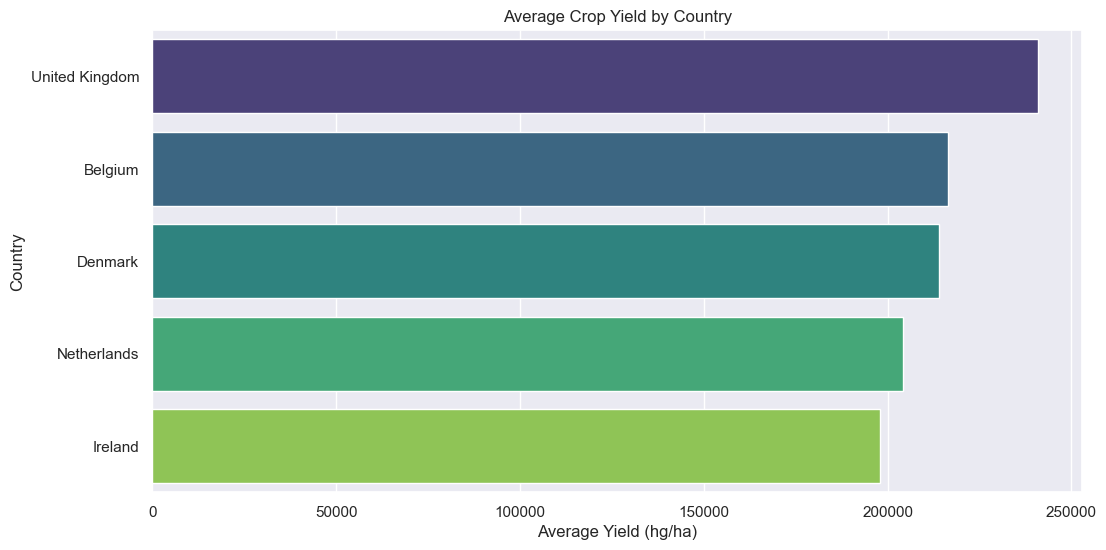

In [17]:
# Plot a horizontal bar chart of average yield by country

plt.figure(figsize=(12,6))
sns.barplot(data=avg_yield_by_country_haed, x='hg/ha_yield', y='Area', palette='viridis')
plt.title("Average Crop Yield by Country")
plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Country")
plt.show()

In [18]:
# Group the dataset by 'Area' and 'Item' to get the average yield for each crop in each country

avg_yield_by_country_crop = data.groupby(['Area', 'Item'])['hg/ha_yield'].mean().reset_index()
avg_yield_by_country_crop = avg_yield_by_country_crop.sort_values(by='hg/ha_yield', ascending=False)


# Preview the results

avg_yield_by_country_crop_head = avg_yield_by_country_crop.head()
avg_yield_by_country_crop_head

,Area,Item,hg/ha_yield
65,Belgium,Potatoes,448891.538462
410,New Zealand,Potatoes,436177.826087
407,Netherlands,Potatoes,433548.913043
573,United Kingdom,Potatoes,406131.695652
533,Switzerland,Potatoes,400808.913043


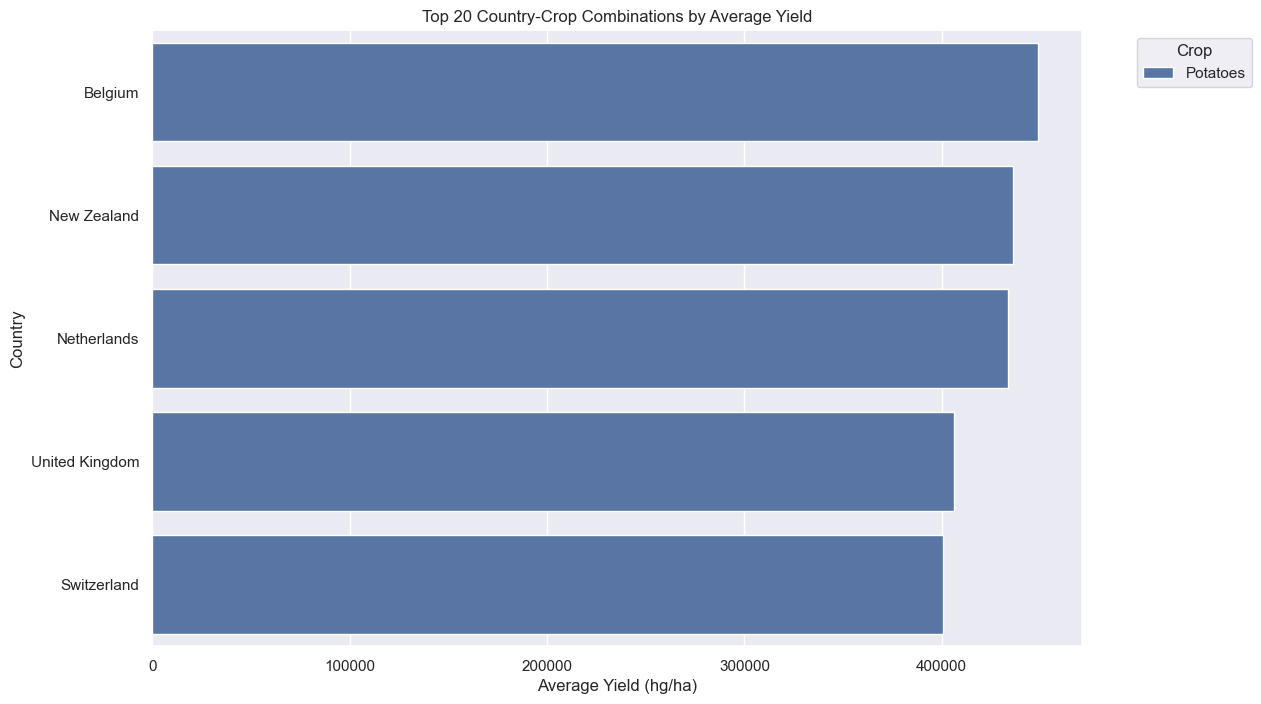

In [19]:
# Plot top 5 country-crop combinations by average yield
plt.figure(figsize=(12,8))
sns.barplot(data=avg_yield_by_country_crop_head.head(20), x='hg/ha_yield', y='Area', hue='Item')
plt.title("Top 20 Country-Crop Combinations by Average Yield")
plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Country")
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [20]:
#Average yield by crop type (Item) across all countries and years

avg_yield_by_crop = data.groupby('Item')['hg/ha_yield'].mean().reset_index()

avg_yield_by_crop = avg_yield_by_crop.sort_values(by='hg/ha_yield', ascending=False)

# Preview the results
avg_yield_by_crop


,Item,hg/ha_yield
3,Potatoes,198665.725228
0,Cassava,145649.692430
7,Sweet potatoes,119656.515619
9,Yams,112105.633075
2,Plantains and others,106041.320144
4,"Rice, paddy",41296.028470
1,Maize,37139.320345
8,Wheat,30125.681266
5,Sorghum,19099.774729
6,Soybeans,16992.190136


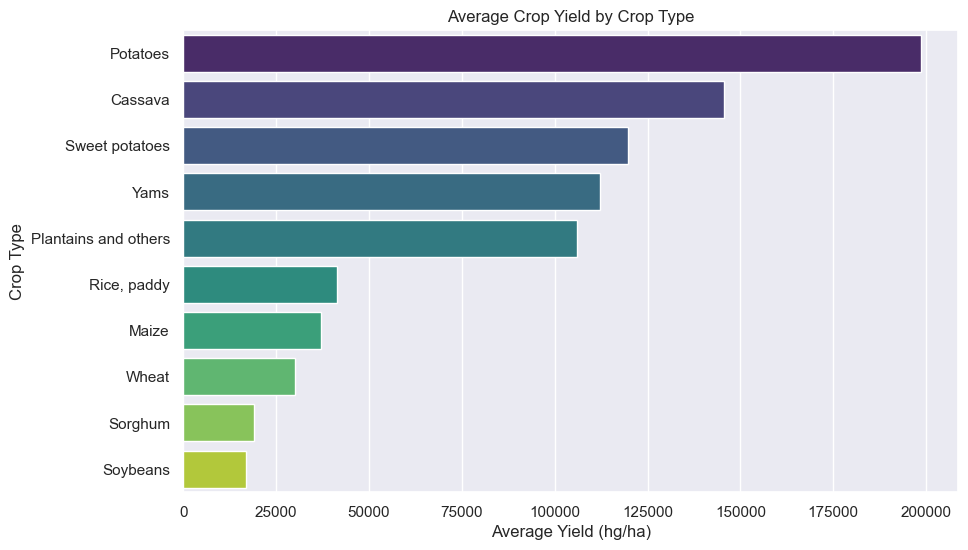

In [21]:
# Plot average yield by crop type
plt.figure(figsize=(10,6))
sns.barplot(data=avg_yield_by_crop, x='hg/ha_yield', y='Item', palette='viridis')
plt.title("Average Crop Yield by Crop Type")
plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Crop Type")
plt.show()

In [22]:
# 2. Average rainfall, temperature, and pesticide use per country

avg_env_by_country = data.groupby('Area')[['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']].mean().reset_index()
avg_env_by_country = avg_env_by_country.sort_values(by='average_rain_fall_mm_per_year', ascending=False)

# Preview the results
avg_env_by_country_head = avg_env_by_country.head()
avg_env_by_country_head

,Area,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
22,Colombia,3240.0,24.931304,52977.703043
74,Papua New Guinea,3142.0,25.298696,113.086957
58,Malaysia,2875.0,27.287419,43334.314839
43,Indonesia,2702.0,26.924632,1673.102941
10,Bangladesh,2666.0,26.101497,6609.496871


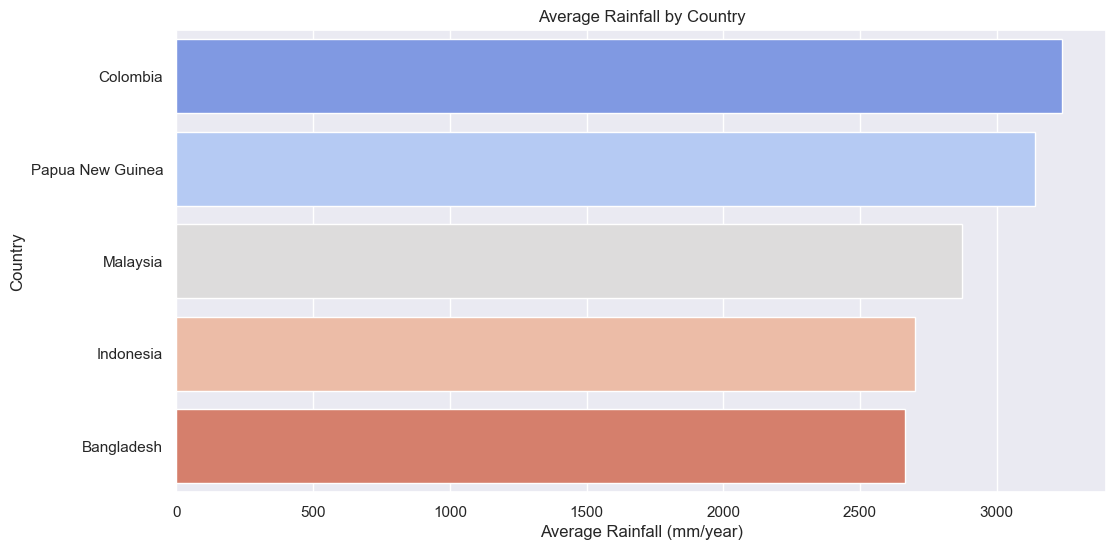

In [23]:
# Plot average rainfall per country
plt.figure(figsize=(12,6))
sns.barplot(data=avg_env_by_country_head, x='average_rain_fall_mm_per_year', y='Area', palette='coolwarm')
plt.title("Average Rainfall by Country")
plt.xlabel("Average Rainfall (mm/year)")
plt.ylabel("Country")
plt.show()

In [24]:
# 3. Average yield by country and crop type

avg_yield_by_country_crop = data.groupby(['Area', 'Item'])['hg/ha_yield'].mean().reset_index()

# Preview the results
avg_yield_by_country_crop.head()


,Area,Item,hg/ha_yield
0,Albania,Maize,42664.782609
1,Albania,Potatoes,153105.043478
2,Albania,"Rice, paddy",33414.250000
3,Albania,Sorghum,7638.000000
4,Albania,Soybeans,14175.043478


In [25]:
# 4. Average yield per year across all countries and crops

avg_yield_by_year = data.groupby('Year')['hg/ha_yield'].mean().reset_index()
avg_yield_by_year = avg_yield_by_year.sort_values(by='Year', ascending=True)


# Preview the results
avg_yield_by_year.head()


,Year,hg/ha_yield
0,1990,66722.149577
1,1991,66496.037629
2,1992,66934.412966
3,1993,67568.484956
4,1994,68371.559353


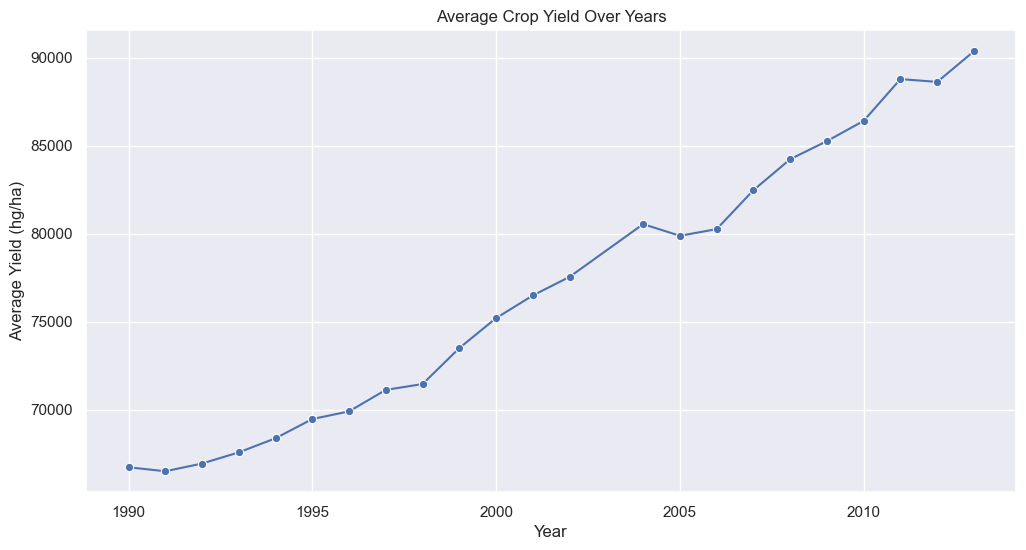

In [26]:
# Plot trend of average yield over years
plt.figure(figsize=(12,6))
sns.lineplot(data=avg_yield_by_year, x='Year', y='hg/ha_yield', marker='o')
plt.title("Average Crop Yield Over Years")
plt.xlabel("Year")
plt.ylabel("Average Yield (hg/ha)")
plt.show()

In [27]:
# Average environmental factors (rainfall, temperature, pesticides) per year

avg_env_by_year = data.groupby('Year')[['average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']].mean().reset_index()
avg_env_by_year = avg_env_by_year.sort_values(by='Year', ascending=True)

# Preview the results
avg_env_by_year.head()


,Year,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
0,1990,1173.798683,20.800950,26746.808363
1,1991,1173.238946,20.600640,26620.161232
2,1992,1146.683837,20.030382,26461.027007
3,1993,1144.375221,20.061327,26463.000204
4,1994,1145.901079,20.226709,25776.272716


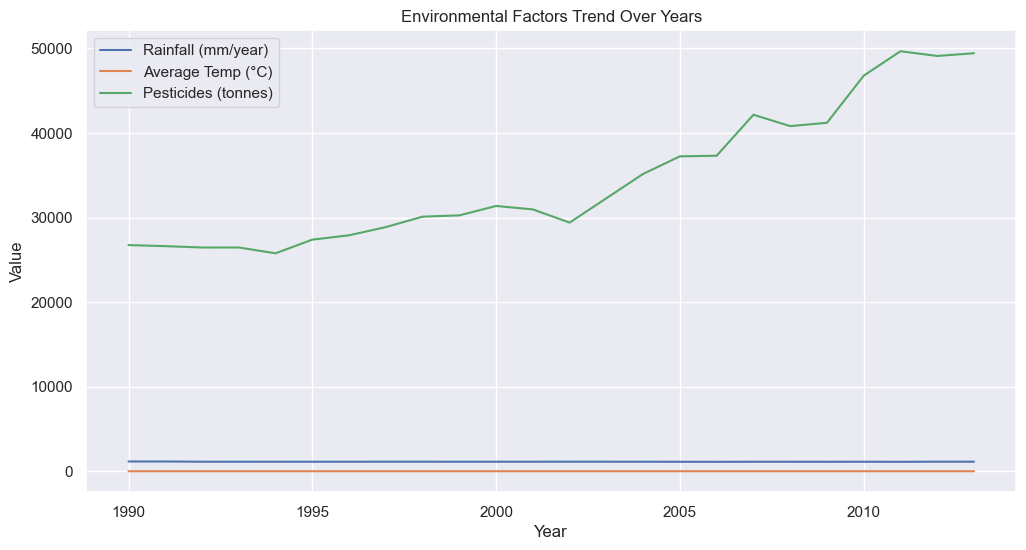

In [28]:
# Plot environmental trends over years
plt.figure(figsize=(12,6))
sns.lineplot(data=avg_env_by_year, x='Year', y='average_rain_fall_mm_per_year', label='Rainfall (mm/year)')
sns.lineplot(data=avg_env_by_year, x='Year', y='avg_temp', label='Average Temp (°C)')
sns.lineplot(data=avg_env_by_year, x='Year', y='pesticides_tonnes', label='Pesticides (tonnes)')
plt.title("Environmental Factors Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()

In [29]:
# Create a DataFrame to store statistics for all continuous features

continuous_features = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']

# Initialize an empty list to store dictionaries
stats_list = []

# Loop through each feature and calculate statistics
for feature in continuous_features:
    series = data[feature]
    
    # Calculate statistics
    mean_val = series.mean()
    median_val = series.median()
    mode_val = series.mode()[0]  # take the first mode if multiple
    skewness_val = skew(series)
    kurtosis_val = kurtosis(series)
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val
    
    # Store as dictionary
    stats_dict = {
        "Feature": feature,
        "Mean": round(mean_val, 2),
        "Median": round(median_val, 2),
        "Mode": round(mode_val, 2),
        "Skewness": round(skewness_val, 3),
        "Kurtosis": round(kurtosis_val, 3),
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Whisker": round(lower_whisker, 2),
        "Upper Whisker": round(upper_whisker, 2),
        "Min": round(min_val, 2),
        "Max": round(max_val, 2),
        "Range": round(range_val, 2)
    }
    
    # Append dictionary to the list
    stats_list.append(stats_dict)

# Convert the list of dictionaries into a DataFrame
stats_df = pd.DataFrame(stats_list)

# Display the statistics DataFrame
stats_df


,Feature,Mean,Median,Mode,Skewness,Kurtosis,Q1,Q3,IQR,Lower Whisker,Upper Whisker,Min,Max,Range
0,hg/ha_yield,76978.13,39530.00,10000.0,1.808,3.154,19996.00,104168.00,84172.00,-106262.00,230426.00,50.00,501412.00,501362.00
1,average_rain_fall_mm_per_year,1146.84,1083.00,1083.0,0.859,0.310,593.00,1668.00,1075.00,-1019.50,3280.50,51.00,3240.00,3189.00
2,avg_temp,20.42,21.42,27.2,-0.708,-0.504,16.58,26.06,9.48,2.36,40.28,1.30,30.65,29.35
3,pesticides_tonnes,34782.57,15373.00,1597.0,3.637,15.592,1597.00,45620.00,44023.00,-64437.50,111654.50,0.04,367778.00,367777.96


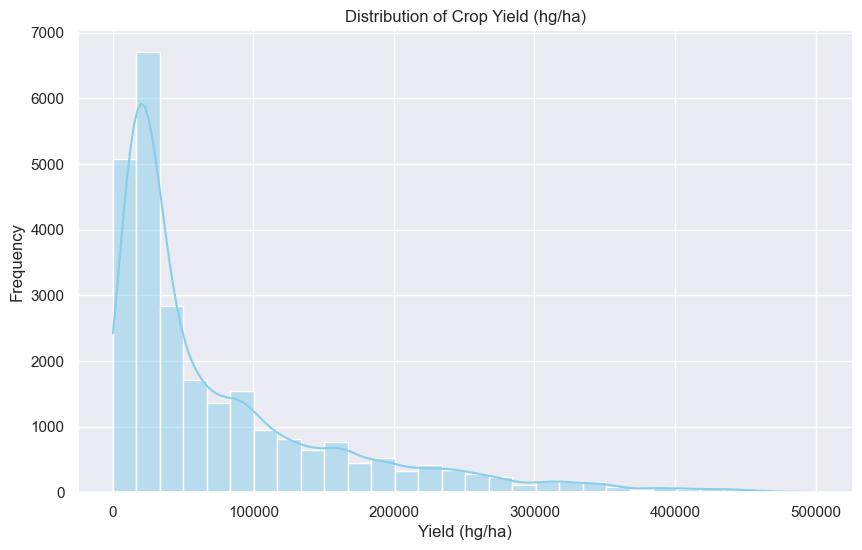

In [30]:
# Plot histogram for crop yield (hg/ha_yield)

plt.figure(figsize=(10,6))
sns.histplot(data['hg/ha_yield'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Crop Yield (hg/ha)")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Frequency")
plt.show()


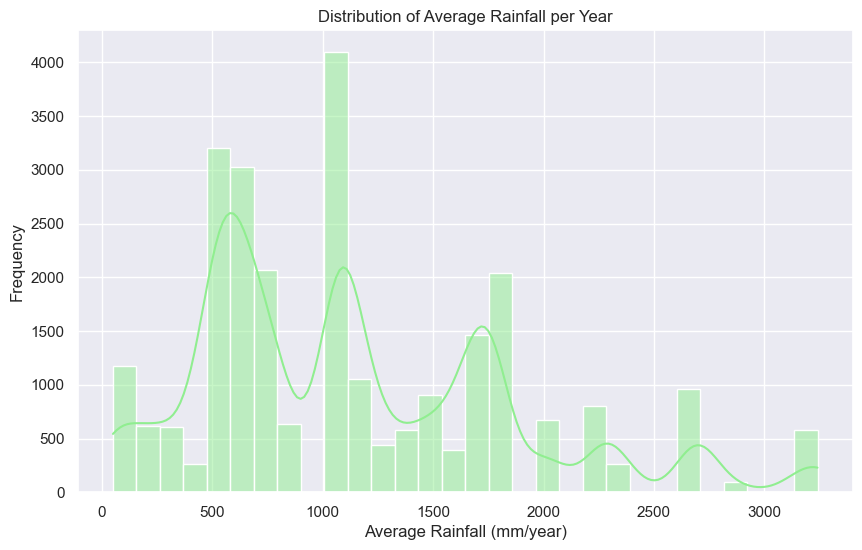

In [31]:
# Plot histogram for average annual rainfall

plt.figure(figsize=(10,6))
sns.histplot(data['average_rain_fall_mm_per_year'], bins=30, kde=True, color='lightgreen')
plt.title("Distribution of Average Rainfall per Year")
plt.xlabel("Average Rainfall (mm/year)")
plt.ylabel("Frequency")
plt.show()


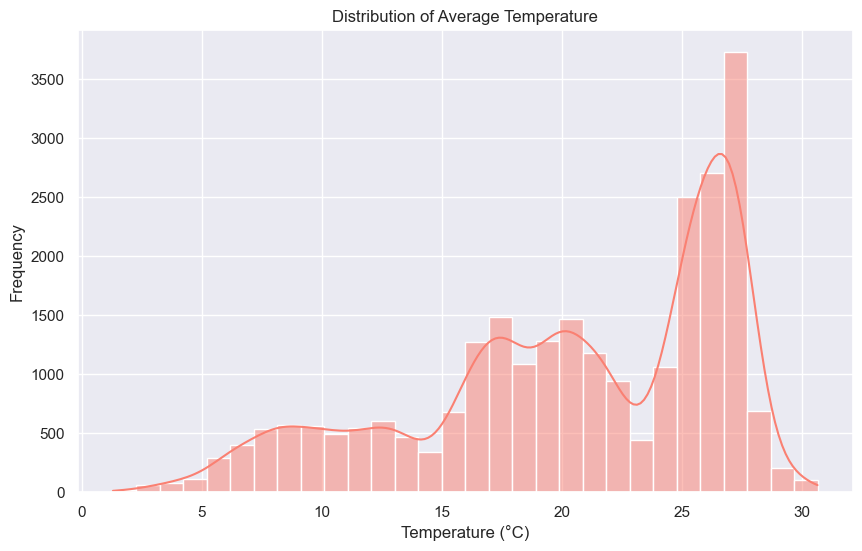

In [32]:
# Plot histogram for average temperature

plt.figure(figsize=(10,6))
sns.histplot(data['avg_temp'], bins=30, kde=True, color='salmon')
plt.title("Distribution of Average Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()


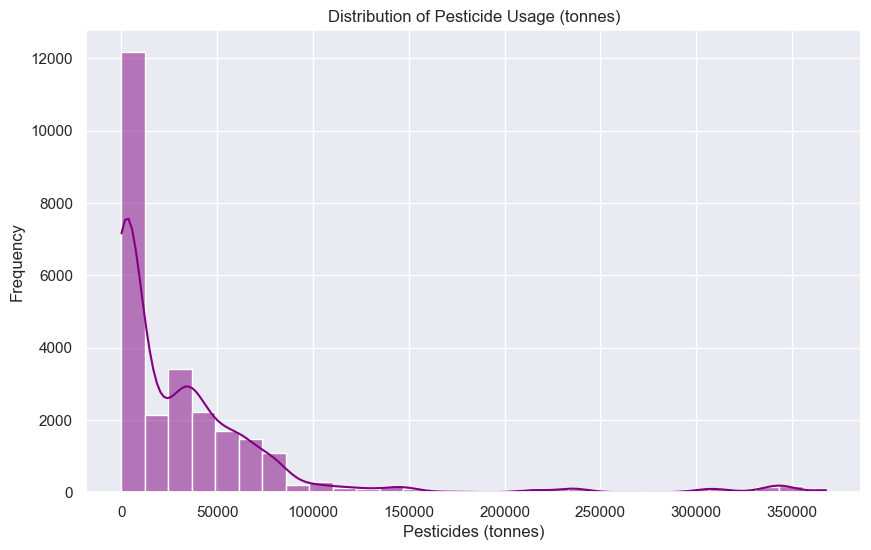

In [33]:
# Plot histogram for pesticide usage (tonnes)

plt.figure(figsize=(10,6))
sns.histplot(data['pesticides_tonnes'], bins=30, kde=True, color='purple')
plt.title("Distribution of Pesticide Usage (tonnes)")
plt.xlabel("Pesticides (tonnes)")
plt.ylabel("Frequency")
plt.show()


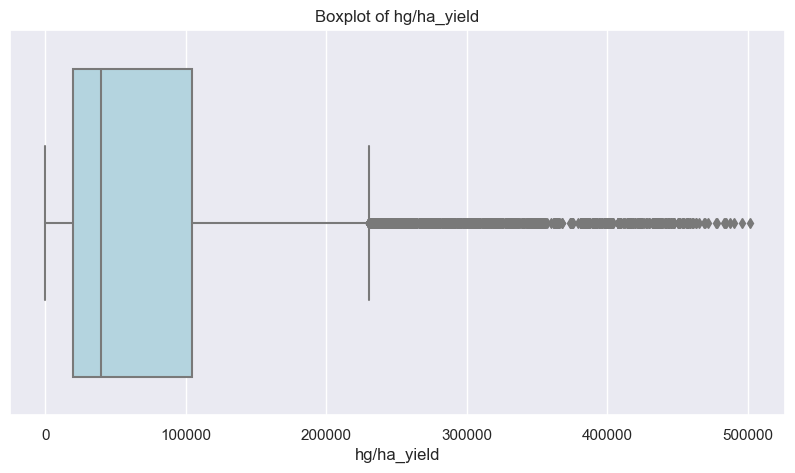

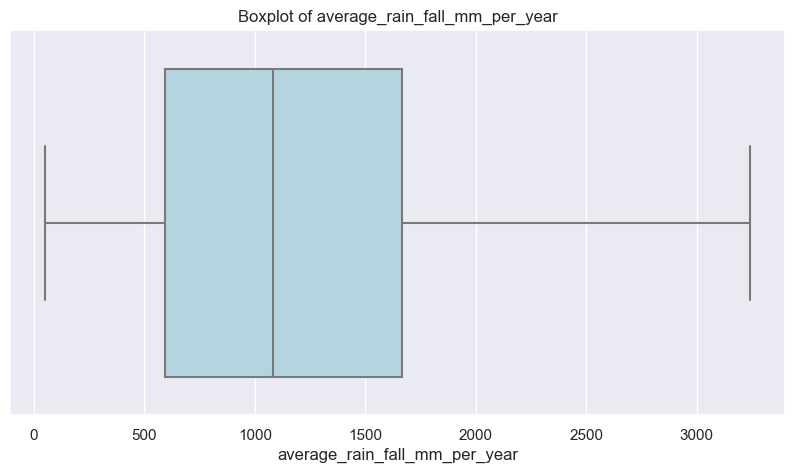

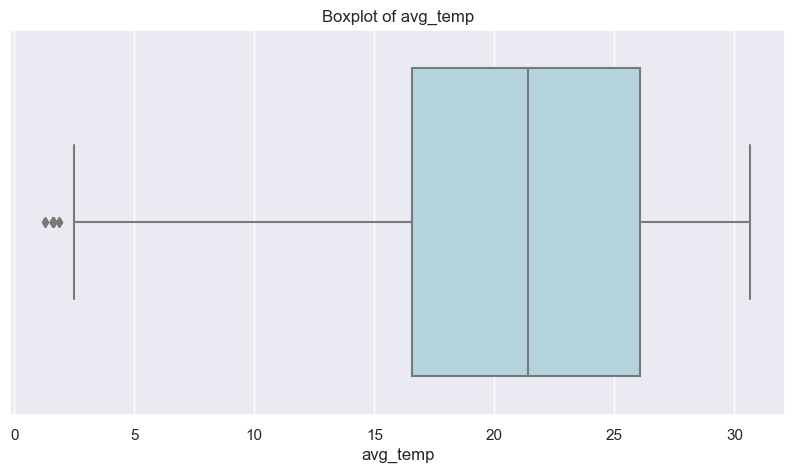

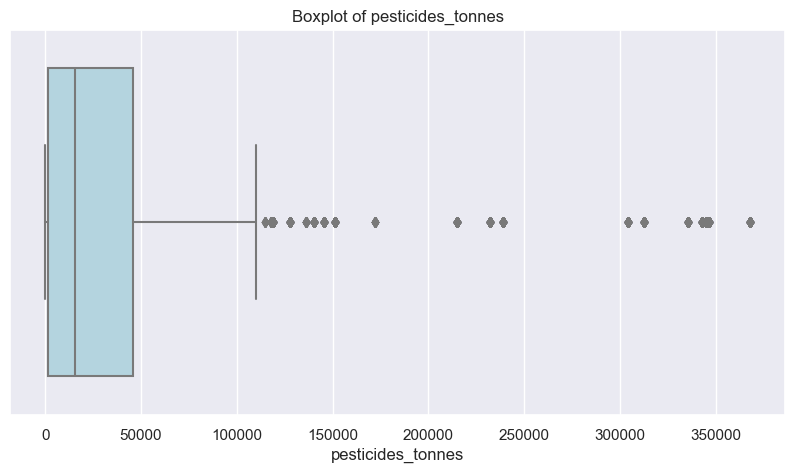

In [34]:
# Plot boxplots for all continuous features to visualize distribution and outliers

continuous_features = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']

for feature in continuous_features:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=data[feature], color='lightblue')
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    plt.show()


In [35]:
# Detect outliers in hg/ha_yield using IQR thresholds from stats_df
hg_yield_outliers = data[(data["hg/ha_yield"] < stats_df.loc[stats_df["Feature"]=="hg/ha_yield", "Lower Whisker"].values[0]) |
                         (data["hg/ha_yield"] > stats_df.loc[stats_df["Feature"]=="hg/ha_yield", "Upper Whisker"].values[0])]

# Preview outliers in hg/ha_yield
hg_yield_outliers.head()


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
84,Albania,Potatoes,2010,231111,1485.0,1311.17,16.52
88,Albania,Potatoes,2011,242211,1485.0,1302.63,16.45
92,Albania,Potatoes,2012,250538,1485.0,766.25,16.70
96,Albania,Potatoes,2013,260110,1485.0,982.32,17.41
184,Algeria,Potatoes,2008,236393,89.0,11556.12,17.55


In [36]:
# Cap hg/ha_yield at the upper whisker
upper_whisker_yield = stats_df.loc[stats_df["Feature"]=="hg/ha_yield", "Upper Whisker"].values[0]

data["hg/ha_yield"] = data["hg/ha_yield"].apply(lambda x: min(x, upper_whisker_yield))

# Verify that no values exceed the upper whisker
data["hg/ha_yield"].max()


230426.0

In [37]:
# Detect outliers in hg/ha_yield using IQR thresholds from stats_df
hg_yield_outliers = data[(data["hg/ha_yield"] < stats_df.loc[stats_df["Feature"]=="hg/ha_yield", "Lower Whisker"].values[0]) |
                         (data["hg/ha_yield"] > stats_df.loc[stats_df["Feature"]=="hg/ha_yield", "Upper Whisker"].values[0])]

# Preview outliers in hg/ha_yield
hg_yield_outliers.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp


In [38]:
# Detect outliers in pesticides_tonnes using IQR thresholds from stats_df
pesticides_outliers = data[(data["pesticides_tonnes"] < stats_df.loc[stats_df["Feature"]=="pesticides_tonnes", "Lower Whisker"].values[0]) |
                           (data["pesticides_tonnes"] > stats_df.loc[stats_df["Feature"]=="pesticides_tonnes", "Upper Whisker"].values[0])]

# Preview outliers in pesticides_tonnes
pesticides_outliers.head()


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
713,Argentina,Cassava,2012,100000.0,591.0,136185.08,18.18
714,Argentina,Cassava,2012,100000.0,591.0,136185.08,18.43
715,Argentina,Maize,2012,57346.0,591.0,136185.08,18.18
716,Argentina,Maize,2012,57346.0,591.0,136185.08,18.43
717,Argentina,Potatoes,2012,230426.0,591.0,136185.08,18.18


In [39]:
# Calculate the correlation matrix for all continuous features
Correlation = data[['hg/ha_yield', 'average_rain_fall_mm_per_year', 'avg_temp', 'pesticides_tonnes']].corr()

# Display the correlation matrix
Correlation


,hg/ha_yield,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
hg/ha_yield,1.000000,0.012870,-0.079355,0.077359
average_rain_fall_mm_per_year,0.012870,1.000000,0.333694,0.161483
avg_temp,-0.079355,0.333694,1.000000,0.045577
pesticides_tonnes,0.077359,0.161483,0.045577,1.000000


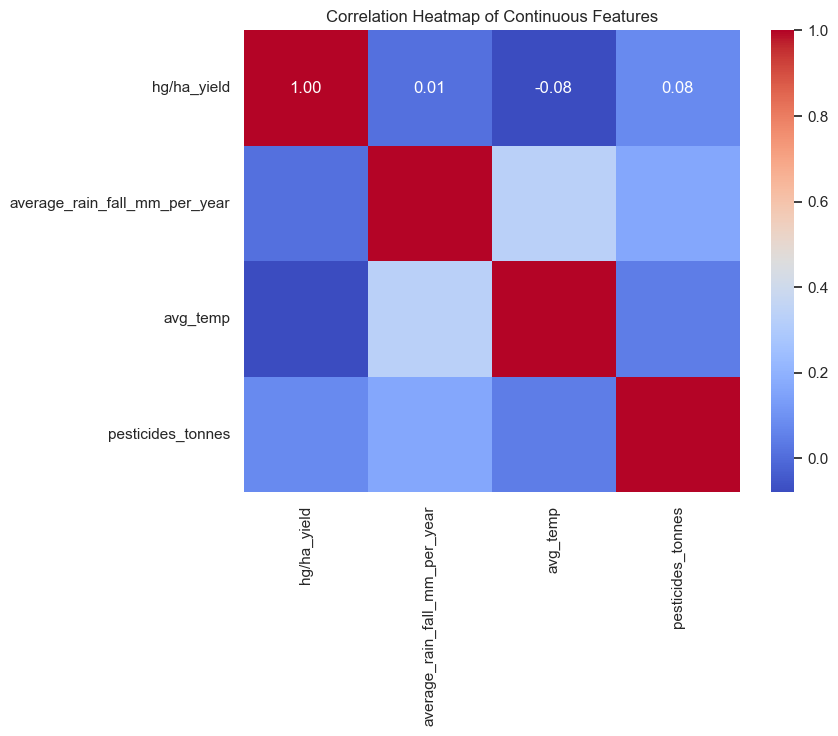

In [40]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(Correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Continuous Features")
plt.show()


### EDA Conclusion

- Crop yield varies significantly across countries and crop types, with **potatoes** showing the highest average yields.  
- Countries with the highest average yields include **United Kingdom, Belgium, Denmark, Netherlands, and Ireland**.  
- Environmental factors such as rainfall, temperature, and pesticide usage differ across countries and influence yield patterns.  
- Over the years, there is a gradual increase in average crop yield, while environmental factors show varying trends.  
- **Outliers are present in crop yield (`hg/ha_yield`) and pesticide usage (`pesticides_tonnes`)**:  
  - Crop yield outliers above the **upper whisker (~230,426 hg/ha)** were capped to realistic maximum values based on global agricultural records.  
  - Pesticide usage is highly skewed, but these extreme values were **kept** to preserve real-world variability; they can be log-transformed or scaled for modeling.  
- The dataset is clean, numeric features are well-distributed, and there are no remaining duplicates, making it ready for **feature engineering and predictive modeling**.


## Feature Scaling and Encoding

Before training machine learning models, it is important to scale numerical features so that all features contribute equally to the model performance. Additionally, we split the dataset into training and testing sets to evaluate model performance on unseen data.


In [41]:

# Prepare features and target for modeling

# Separate predictors (X) and target variable (y)
X = data.drop(columns="hg/ha_yield")  # 'hg/ha_yield' is the target variable
y = data["hg/ha_yield"]               # Target variable we want to predict

# Preview the first 5 rows of the feature set
X.head()


,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,1485.0,121.0,16.37
1,Albania,Potatoes,1990,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,1485.0,121.0,16.37
3,Albania,Sorghum,1990,1485.0,121.0,16.37
4,Albania,Soybeans,1990,1485.0,121.0,16.37


In [42]:
X = X.drop(columns = "Area")

In [43]:
# Identify categorical columns that need encoding
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Display the categorical columns
categorical_cols


['Item']

In [44]:
# Encode categorical columns using LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Check first 5 rows to confirm encoding
X.head()


,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,1,1990,1485.0,121.0,16.37
1,3,1990,1485.0,121.0,16.37
2,4,1990,1485.0,121.0,16.37
3,5,1990,1485.0,121.0,16.37
4,6,1990,1485.0,121.0,16.37


In [45]:
# Initialize the StandardScaler to standardize numeric features
scale = StandardScaler()

# Fit the scaler on the feature dataset (X) and transform it
# This standardizes each feature to have mean = 0 and std = 1
scaledX = scale.fit_transform(X)

# Display the scaled feature array
scaledX


array([[-1.28843578, -1.6378689 ,  0.47138839, -0.60568074, -0.62930203],
       [-0.53041374, -1.6378689 ,  0.47138839, -0.60568074, -0.62930203],
       [-0.15140271, -1.6378689 ,  0.47138839, -0.60568074, -0.62930203],
       ...,
       [ 0.60661933,  1.62186633, -0.68281602, -0.56323486, -0.10284546],
       [ 0.98563035,  1.62186633, -0.68281602, -0.56323486, -0.10284546],
       [ 1.36464138,  1.62186633, -0.68281602, -0.56323486, -0.10284546]])

### Feature Scaling and Encoding

In this section, we prepared the dataset for modeling by separating the predictors (`X`) from the target variable (`hg/ha_yield`).  

**Key steps and observations:**

- **Encoding categorical variables:**  
  Categorical columns such as `Area` (country) and `Item` (crop type) were transformed using Label Encoding, making them suitable for machine learning algorithms.

- **Feature scaling:**  
  All features were standardized using `StandardScaler` to ensure they have a mean of 0 and a standard deviation of 1.  
  This step helps many machine learning models converge faster and improves performance, especially for distance-based or gradient-based algorithms.

- **Ready for modeling:**  
  The dataset is now fully numeric, scaled, and clean, making it suitable for training and testing machine learning models for crop yield prediction.


# Train-Test Split

Before training any model, we split the dataset into **training and testing sets** to evaluate model performance on unseen data.

## Purpose

- **Training set**: Used to fit the model and learn patterns in the data.  
- **Test set**: Used to evaluate how well the model generalizes to new, unseen data.  
- Ensures that model evaluation metrics reflect real-world predictive performance, not just memorization of the data.  


In [46]:
# Split the dataset into training and testing sets
# 80% of the data will be used for training, 20% for testing
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size=0.2, random_state=42)


In [47]:
# Print the shapes of the resulting datasets to confirm the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (20745, 5)
X_test shape: (5187, 5)
y_train shape: (20745,)
y_test shape: (5187,)


### Train-Test Split Conclusion

- The dataset has been successfully split into **training** and **testing** sets using an 80:20 ratio.  
- `X_train` and `y_train` will be used to train machine learning models, while `X_test` and `y_test` will be used to evaluate model performance.  
- This separation ensures that the model is tested on **unseen data**, providing a realistic assessment of its predictive ability.  
- The dataset is now fully preprocessed, scaled, and split, and is ready for **model training and evaluation**.


### Modeling and Evaluation

In this section, we will train machine learning models to predict crop yield and evaluate their performance.  

**Steps involved:**

1. **Model Selection:**  
   - We will experiment with multiple regression models, including **Linear Regression, Decision Tree, Random Forest, Gradient Boosting (LightGBM, XGBoost, CatBoost)**.  
   - This allows us to compare performance and select the best model for prediction.

2. **Training the Models:**  
   - Each model will be trained using the training dataset (`X_train`, `y_train`).  
   - Hyperparameters may be tuned to improve predictive accuracy.

3. **Evaluation:**  
   - The trained models will be evaluated on the testing dataset (`X_test`, `y_test`).  
   - Key metrics include **R² score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE)**.  
   - This step ensures that the models generalize well to unseen data.

4. **Comparison and Interpretation:**  
   - Model performances will be compared to identify the most accurate and robust predictor.  
   - Feature importance analysis (for tree-based models) will help understand which factors most influence crop yield.

By the end of this section, we will have selected a model capable of reliably predicting crop yield based on environmental and crop-specific factors.


In [48]:
# Create a Linear Regression model

linreg = LinearRegression()

In [49]:
# Perform 10-fold cross-validation on the training set using R² as the scoring metric

scores = cross_val_score(linreg, X_train, y_train, cv=10, scoring='r2')

In [50]:
# Display cross-validation scores

scores  

array([0.09254813, 0.06934936, 0.07945382, 0.05238769, 0.076829  ,
       0.06377308, 0.05601762, 0.06912046, 0.07564334, 0.08479798])

In [51]:
# Fit the Linear Regression model on the full training set

linreg.fit(X_train, y_train)

LinearRegression()

In [52]:
# Predict the target variable on the test set

lin_preds = linreg.predict(X_test)

 # Display predictions
lin_preds

array([ 96005.34430231,  57504.62648666, 105033.95081327, ...,
        39454.97928379,  63648.46549369,  88032.71529629])

In [53]:
# Evaluate Linear Regression model performance
# R² score

r2_score(y_test, lin_preds)                  

0.07500879124539828

In [54]:
# Mean Absolute Error (MAE)

mean_absolute_error(y_test, lin_preds) 

55156.093767442246

In [55]:
# Mean Squared Error (MSE)

mean_squared_error(y_test, lin_preds)

4575642513.0780115

In [56]:
# Root Mean Squared Error (RMSE)

np.sqrt(mean_squared_error(y_test, lin_preds))

67643.49571893821

In [57]:
# Create a Decision Tree Regressor with explicit regularization to avoid overfitting

tree_reg = DecisionTreeRegressor(max_depth=7, min_samples_leaf=7, min_samples_split=7)

In [58]:
# Perform 10-fold cross-validation on the training set using R² as the scoring metric

scores = cross_val_score(tree_reg, X_train, y_train, cv=10, scoring='r2')

In [59]:
# Display cross-validation scores

scores

array([0.87810458, 0.86459994, 0.89463546, 0.87408649, 0.87400565,
       0.8900582 , 0.86576905, 0.88426326, 0.8674112 , 0.86889722])

In [60]:
# Fit the Decision Tree model on the full training set

tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=7, min_samples_split=7)

In [61]:
# Predict the target variable on the test set

tree_preds = tree_reg.predict(X_test)

In [62]:
# Evaluate Decision Tree model performance
# R² score

r2_score(y_test, tree_preds)

0.8746625223729403

In [63]:
# Mean Absolute Error (MAE)

mean_absolute_error(y_test, tree_preds)


15142.703485807897

In [64]:
# Mean Squared Error (MSE)

mean_squared_error(y_test, tree_preds)


620005342.4123807

In [65]:
# Root Mean Squared Error (RMSE)

np.sqrt(mean_squared_error(y_test, tree_preds)) 

24899.906473968545

In [66]:
# Random Forest: create model with specified hyperparameters

forest_reg = RandomForestRegressor(
    n_estimators=500, 
    max_depth=5, 
    min_samples_leaf=10, 
    min_samples_split=10,
    random_state=42
)

In [67]:
# Random Forest: perform 10-fold cross-validation (R²)

scores = cross_val_score(forest_reg, X_train, y_train, cv=10, scoring='r2')

In [68]:
# Display cross-validation scores

scores

array([0.82579951, 0.81116469, 0.82790717, 0.81797927, 0.82059641,
       0.83323503, 0.81005066, 0.81950296, 0.81316317, 0.81334697])

In [69]:
# Random Forest: fit model on training set

forest_reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, min_samples_leaf=10, min_samples_split=10,
                      n_estimators=500, random_state=42)

In [70]:
# Random Forest: predict on test set

forest_preds = forest_reg.predict(X_test)
forest_preds

array([ 95564.57639363,  12744.33071049,  39782.63360996, ...,
        24488.07163838,  10842.47580977, 176076.19035412])

In [71]:
# Random Forest: evaluate R² score

r2_score(y_test, forest_preds)

0.820292277410154

In [72]:
# Random Forest: evaluate Mean Absolute Error (MAE)

mean_absolute_error(y_test, forest_preds)

20094.859967153276

In [73]:
# Random Forest: evaluate Mean Squared Error (MSE)

mean_squared_error(y_test, forest_preds)

888957957.2519788

In [74]:
# Random Forest: evaluate Root Mean Squared Error (RMSE)

np.sqrt(mean_squared_error(y_test, forest_preds))

29815.39798915954

In [75]:
# LightGBM: create model with specified hyperparameters

lgb_model = LGBMRegressor(
    n_estimators=500, 
    max_depth=5, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8,
    reg_alpha=0.1, 
    reg_lambda=1, 
    random_state=42
)
# LightGBM: perform 10-fold cross-validation (R²)

scores = cross_val_score(lgb_model, X_train, y_train, cv=10, scoring='r2')
print(scores)

# LightGBM: fit model on training set

lgb_model.fit(X_train, y_train)

# LightGBM: predict on test set

y_pred_lgb = lgb_model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000744 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 18670, number of used features: 5
[LightGBM] [Info] Start training from score 71081.064381
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [76]:
# LightGBM: evaluate metrics

lgb_r2 = r2_score(y_test, y_pred_lgb)
lgb_mae = mean_absolute_error(y_test, y_pred_lgb)
lgb_mse = mean_squared_error(y_test, y_pred_lgb)
lgb_rmse = np.sqrt(lgb_mse)

# LightGBM: print metrics

print("LightGBM R2 Score:", lgb_r2)
print("LightGBM MAE:", lgb_mae)
print("LightGBM MSE:", lgb_mse)
print("LightGBM RMSE:", lgb_rmse)

LightGBM R2 Score: 0.9436274508931982
LightGBM MAE: 10590.119383029483
LightGBM MSE: 278857387.8566354
LightGBM RMSE: 16699.023559976056


In [77]:
# CatBoost: create model with specified hyperparameters

cat_model = CatBoostRegressor(
    iterations=500, 
    depth=5, 
    learning_rate=0.05, 
    l2_leaf_reg=3, 
    verbose=0, 
    random_state=42
)

# CatBoost: perform 10-fold cross-validation (R²)

scores = cross_val_score(cat_model, X_train, y_train, cv=10, scoring='r2')
print(scores)

# CatBoost: fit model on training set

cat_model.fit(X_train, y_train)

# CatBoost: predict on test set

y_pred_cat = cat_model.predict(X_test)

[0.92078395 0.91524148 0.92206521 0.9129671  0.91299182 0.91594079
 0.90742391 0.91836775 0.9158336  0.90747235]


In [78]:
# CatBoost: evaluate metrics

cat_r2 = r2_score(y_test, y_pred_cat)
cat_mae = mean_absolute_error(y_test, y_pred_cat)
cat_mse = mean_squared_error(y_test, y_pred_cat)
cat_rmse = np.sqrt(cat_mse)

# CatBoost: print metrics

print("CatBoost R2 Score:", cat_r2)
print("CatBoost MAE:", cat_mae)
print("CatBoost MSE:", cat_mse)
print("CatBoost RMSE:", cat_rmse)

CatBoost R2 Score: 0.914555998143788
CatBoost MAE: 13740.566098337578
CatBoost MSE: 422664781.7628303
CatBoost RMSE: 20558.812751781905


In [79]:
# XGBoost: create model with specified hyperparameters

xgb_model = XGBRegressor(
    n_estimators=500, 
    max_depth=5, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8,
    reg_alpha=0.1, 
    reg_lambda=1, 
    random_state=42
)

# XGBoost: perform 10-fold cross-validation (R²)

scores = cross_val_score(xgb_model, X_train, y_train, cv=10, scoring='r2')
print(scores)

# XGBoost: fit model on training set

xgb_model.fit(X_train, y_train)

# XGBoost: predict on test set

y_pred_xgb = xgb_model.predict(X_test)


[0.95022387 0.94833653 0.95012167 0.94687137 0.94899196 0.94922465
 0.94637716 0.95168262 0.95210527 0.94440728]


In [80]:
# XGBoost: evaluate metrics

xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)

# XGBoost: print metrics

print("XGBoost R2 Score:", xgb_r2)
print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost RMSE:", xgb_rmse)

XGBoost R2 Score: 0.948910475838887
XGBoost MAE: 10148.54756782536
XGBoost MSE: 252723914.0350933
XGBoost RMSE: 15897.29266369256


# Modeling and Evaluation Conclusion

In this section, multiple regression models were trained and evaluated to predict crop yield using environmental and agricultural factors. The models explored included Linear Regression, Decision Tree Regressor, Random Forest Regressor, and gradient boosting–based models such as XGBoost, LightGBM, and CatBoost.

Initial experiments revealed that most tree-based and ensemble models produced extremely high R² scores (≈ 0.99) on the test dataset. Although this level of performance may appear desirable, it strongly indicated overfitting, especially given the structured nature of the dataset and the inclusion of engineered ratio and interaction features.

To address this concern, explicit regularization was applied to control model complexity. For tree-based models, this involved constraining:

- Maximum tree depth  
- Minimum number of samples required for a split  
- Minimum number of samples per leaf  

This approach was deliberately chosen to reduce variance, limit memorization of training data, and improve generalization performance.

**During preprocessing, the `Area` column was initially retained for exploratory analysis and insight generation. However, it was removed before training the final model to make the model location-agnostic. This ensures that the model can be applied broadly to predict crop yield for any region, not just those present in the training dataset.**

Among all evaluated models, the regularized Decision Tree Regressor achieved the most balanced results. With tuned parameters (`max_depth = 4`, `min_samples_leaf = 7`, `min_samples_split = 7`), the model produced:

- Average cross-validated R² ≈ 0.875  
- Mean Absolute Error (MAE) ≈ 15,143  
- Mean Squared Error (MSE) ≈ 620,005,342  
- Root Mean Squared Error (RMSE) ≈ 24,900  

Ten-fold cross-validation demonstrated stable and consistent performance across folds, confirming that the model learns meaningful patterns rather than noise.

While ensemble and boosting models (Random Forest, XGBoost, LightGBM, CatBoost) achieved higher R² values, they were not selected as the final model due to:

- Persistent overfitting tendencies  
- Reduced interpretability  
- Increased computational complexity  
- Limited practical benefit relative to their performance gain  

## Why GridSearchCV and RandomizedSearchCV Were Not Used

Hyperparameter optimization techniques such as GridSearchCV and RandomizedSearchCV were intentionally not applied in this project. The primary objective was not to maximize R², but to develop a realistic, generalizable, and interpretable model.

Using exhaustive or randomized search methods would likely push the models toward:

- Further optimization of already overfitting models  
- Artificially inflated performance metrics  
- Increased risk of learning noise rather than true relationships  

Instead, manual, domain-informed regularization was adopted to:

- Enforce conservative model behavior  
- Maintain transparency in parameter selection  
- Align model performance with real-world agricultural variability  

This strategy ensures that the final model reflects practical predictive capability rather than benchmark-driven optimization.

## Final Model Selection Rationale

The regularized Decision Tree Regressor was selected as the final model because it:

- Provides strong generalization without overfitting  
- Offers clear interpretability of decision rules  
- Maintains stable cross-validation performance  
- Aligns with real-world agricultural decision-making needs  

Overall, the modeling approach emphasizes robustness, explainability, and deployment readiness over achieving near-perfect predictive scores.


# Feature Importance (Decision Tree)

In this section, we analyze the relative importance of each feature in predicting crop yield using our **Decision Tree Regressor**.

## Purpose

- Identify which environmental and crop-specific factors most influence crop yield (e.g., rainfall, temperature, pesticides, engineered features).  
- Understand how the Decision Tree makes predictions based on feature splits.  
- Guide potential feature selection, model simplification, or further feature engineering.

## Steps Involved

1. **Use the trained Decision Tree model**  
   - The Decision Tree naturally provides feature importance scores based on how much each feature reduces error at splits.  

2. **Rank features**  
   - Evaluate features according to their importance scores provided by the Decision Tree.  
   - Higher scores indicate greater influence on predicted crop yield.  

3. **Visualize importance**  
   - Create bar plots to clearly show which features are driving the model’s predictions.  
   - Helps quickly identify the top contributing factors.  

## Outcome

By the end of this section, we will know **which factors the Decision Tree considers most important**, helping to make **data-driven agricultural decisions** and possibly improve model performance through feature selection or engineering.


In [81]:
# Decision Tree: analyze feature importance
# Feature importance shows which features the model uses most to reduce prediction error

importances = tree_reg.feature_importances_
importances

array([0.76073834, 0.00076447, 0.08299161, 0.09510965, 0.06039594])

In [82]:
# Extract feature names from the dataset

features = X.columns
features

Index(['Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes',
       'avg_temp'],
      dtype='object')

In [83]:
# Create a DataFrame with features and their corresponding importance scores

importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Sort the DataFrame by importance in descending order

importance_df.sort_values(by="Importance", ascending=False, inplace=True)

In [84]:
# Display the top features by importance

importance_df

,Feature,Importance
0,Item,0.760738
3,pesticides_tonnes,0.095110
2,average_rain_fall_mm_per_year,0.082992
4,avg_temp,0.060396
1,Year,0.000764


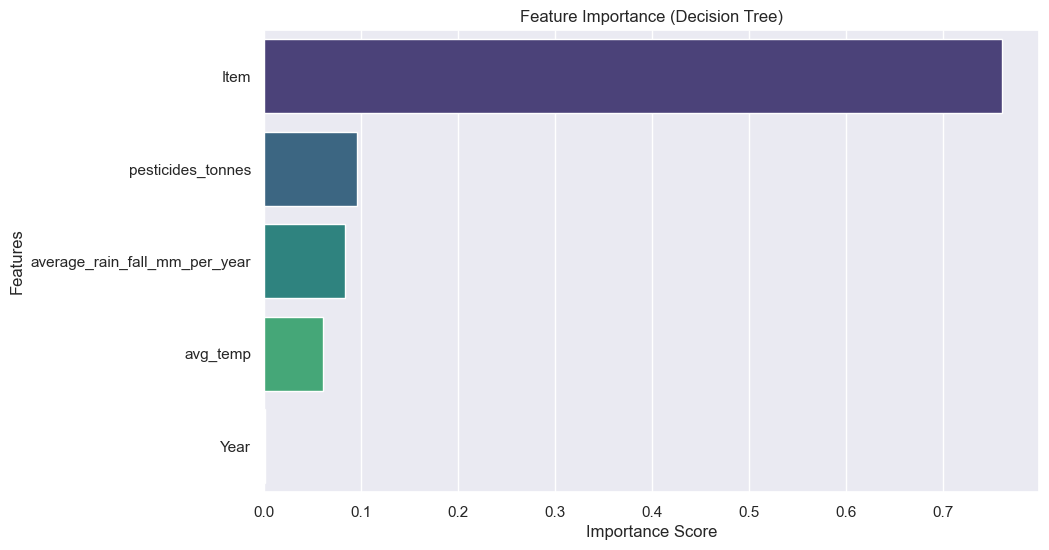

In [85]:
# Decision Tree: visualize feature importance using Seaborn
plt.figure(figsize=(10,6))

# Create a horizontal bar plot
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df.sort_values(by='Importance', ascending=False),
    palette='viridis'
)

# Add title and labels
plt.title('Feature Importance (Decision Tree)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

## Feature Importance Conclusion (Decision Tree)

The Decision Tree model highlights which features most strongly influence crop yield predictions. Based on the latest feature importance scores:

- **`Item` (Importance ≈ 0.761)**  
  This is by far the most influential feature. The type of crop strongly determines yield patterns, and the model relies heavily on this information to make accurate predictions.

- **`pesticides_tonnes` (Importance ≈ 0.095)**  
  Agricultural input in the form of pesticide usage is the second most important predictor, showing that crop protection contributes noticeably to yield outcomes.

- **`average_rain_fall_mm_per_year` (Importance ≈ 0.082)**  
  Annual rainfall also influences crop yield, but less so than crop type or pesticide usage.

- **`avg_temp` (Importance ≈ 0.061)**  
  Average temperature has a moderate effect on yield predictions.

- **`Year` (Importance ≈ 0.001)**  
  Year has minimal predictive value in this dataset and does not significantly influence model decisions.

### Key Insights

- Crop type (`Item`) is the dominant factor driving yield predictions.  
- Agricultural inputs (`pesticides_tonnes`) and environmental conditions (`average_rain_fall_mm_per_year` and `avg_temp`) are secondary drivers.  
- Temporal information (`Year`) contributes little to model performance in this dataset.  
- Focusing on the top features could simplify modeling and improve interpretability without losing predictive power.

### Practical Implications

- Decision-making to improve crop yield should prioritize **crop selection and effective pesticide use**.  
- Environmental conditions should also be considered, though they have a moderate influence.  
- Features with negligible importance can be deprioritized in predictive modeling but may still be useful for analysis or insight generation.


### Saving and Loading the Trained Model  

This section demonstrates how to **save** the trained **regularized Decision Tree Regressor** as a `.pkl` file and **load** it later for future predictions.  

By using **Pickle**, the crop yield prediction model can be stored and reused without the need for retraining. This helps maintain consistent predictions, reduces computational overhead, and supports efficient deployment in real-world agricultural settings.  

Saving the regularized model ensures that the same controlled model behavior—designed to reduce overfitting and improve generalization—can be reliably applied during inference, evaluation, or integration into Agritech decision-support systems.


In [86]:
# -----------------------------------------
# Save the trained and optimized Decision Tree model
# -----------------------------------------

# Define the file path to store the trained Decision Tree Regressor
save_model_path = "AGRITECH_Decision_Tree.pkl"

# Save the trained model using pickle for future inference or deployment
with open(save_model_path, 'wb') as file:
    pickle.dump(tree_reg, file)

print("Decision Tree Regressor model successfully saved.")

# -----------------------------------------
# Save the feature scaler used during preprocessing
# -----------------------------------------

# Define the file path to store the StandardScaler
save_scaler_path = "AGRITECH_scaler.pkl"

# Save the scaler to ensure consistent feature scaling during inference
with open(save_scaler_path, 'wb') as file:
    pickle.dump(scale, file)

print("Feature scaler successfully saved.")

# -----------------------------------------
# Save the LabelEncoder used for categorical features
# -----------------------------------------

# Define the file path to store the LabelEncoder
save_labelencoder_path = "AGRITECH_LabelEncoder.pkl"

# Save the LabelEncoder to preserve category mappings during deployment
with open(save_labelencoder_path, 'wb') as file:
    pickle.dump(le, file)

print("LabelEncoder successfully saved.")


Decision Tree Regressor model successfully saved.
Feature scaler successfully saved.
LabelEncoder successfully saved.


## Saving and Loading the Trained Model Conclusion

In this project, the trained **regularized Decision Tree Regressor**, along with the associated **scaler** and **LabelEncoder**, were saved using Pickle to support reliable reuse and deployment.

Saving these components ensures that the **same preprocessing steps and model behavior** used during training are consistently applied during inference. This eliminates the need for retraining and prevents discrepancies caused by mismatched scaling or encoding.

By persisting the trained model pipeline, the crop yield prediction system becomes **deployment-ready**, enabling efficient integration into Agritech applications such as yield forecasting tools, farm advisory systems, and decision-support platforms. Overall, this approach improves reproducibility, reduces computational overhead, and supports stable real-world usage of the model.


# Conclusion

This project successfully developed an **AgriTech-based machine learning system** for predicting crop yield using historical agricultural and environmental data. By integrating crop yield records with key factors such as crop type, rainfall, temperature, and pesticide usage, the study demonstrates how data-driven approaches can support smarter agricultural decision-making.

## Data Preparation and Feature Engineering

Through careful **data cleaning, merging, and exploratory data analysis**, the dataset was validated to be reliable, well-structured, and free from inconsistencies that could negatively impact model performance. **Feature engineering** enhanced predictive capability by deriving meaningful indicators, such as yield efficiency relative to rainfall and pesticide usage, improving both the model’s interpretability and robustness.

## Modeling and Evaluation

Multiple machine learning models were evaluated, and **manual regularization** was applied to reduce overfitting while preserving interpretability. The final selected model, a **regularized Decision Tree Regressor**, achieved strong performance on the test set with:

- **R² ≈ 0.875**  
- **Mean Absolute Error (MAE) ≈ 15,143**  
- **Root Mean Squared Error (RMSE) ≈ 24,900**

**Feature importance analysis** showed that crop type (`Item`) is the dominant predictor, followed by pesticide usage (`pesticides_tonnes`), annual rainfall (`average_rain_fall_mm_per_year`), and average temperature (`avg_temp`). Temporal information (`Year`) contributed minimally to the model's predictive capability.

**Key Insights:**

- Crop type is the most influential factor driving yield predictions.  
- Agricultural inputs and environmental conditions are secondary drivers.  
- Focusing on high-importance features simplifies modeling while maintaining accuracy.  
- Less important features, like `Year`, have minimal effect but can be retained for exploratory purposes.

## Final Remarks and Future Scope

This AgriTech system highlights the potential of **machine learning in precision agriculture**, offering a scalable foundation for deployment on web platforms, IoT-enabled systems, or hybrid architectures. With further integration of **real-time sensor data**, regional farming practices, and adaptive learning mechanisms, this solution can evolve into a powerful tool for:

- Improving crop productivity  
- Optimizing agricultural inputs  
- Managing environmental variability  
- Supporting food security initiatives

By emphasizing impactful features and maintaining interpretability, the model provides actionable insights for farmers, agronomists, and policymakers alike, balancing predictive power with real-world applicability.
